<a href="https://colab.research.google.com/github/janampag/TelecomX/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [20]:
import pandas as pd

url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
df = pd.read_json(url)

df.head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [21]:
df.info()

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [22]:
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

df_final = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [23]:
import numpy as np
df_final = df_final.replace('', np.nan)

print("Valores nulos por columna:")
print(df_final.isnull().sum())

print(f"\nRegistros duplicados: {df_final.duplicated().sum()}")

print("\nDistribución de la columna Churn:")
print(df_final['Churn'].value_counts(dropna=False))

Valores nulos por columna:
customerID            0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
Charges.Monthly       0
Charges.Total         0
dtype: int64

Registros duplicados: 0

Distribución de la columna Churn:
Churn
No     5174
Yes    1869
NaN     224
Name: count, dtype: int64


#🔧 Transformación

In [24]:
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

df_final = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

df_final = df_final.replace('', np.nan)

df_final.dropna(subset=['Churn'], inplace=True)

df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')

print(f"Nulos en Charges.Total: {df_final['Charges.Total'].isnull().sum()}")
df_final.info()

Nulos en Charges.Total: 11
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          70

In [25]:
df_final['Charges.Total'] = df_final['Charges.Total'].fillna(df_final['Charges.Monthly'])

print(f"Nulos restantes en Charges.Total: {df_final['Charges.Total'].isnull().sum()}")

Nulos restantes en Charges.Total: 0


In [12]:
print(df_final.columns)

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')


In [26]:
df_final['Cuentas_Diarias'] = (df_final['Charges.Monthly'] / 30).round(2)

print("Vista de las columnas de cargos:")
display(df_final[['Charges.Monthly', 'Cuentas_Diarias']].head())

Vista de las columnas de cargos:


,Charges.Monthly,Cuentas_Diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


In [27]:
columnas_espanol = {
    'customerID': 'ID_Cliente',
    'Churn': 'Abandono',
    'gender': 'Genero',
    'SeniorCitizen': 'Adulto_Mayor',
    'Partner': 'Socio',
    'Dependents': 'Dependientes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Multiples_Lineas',
    'InternetService': 'Servicio_Internet',
    'OnlineSecurity': 'Seguridad_Online',
    'OnlineBackup': 'Respaldo_Online',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Peliculas',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Facturacion_Electronica',
    'PaymentMethod': 'Metodo_Pago',
    'Charges.Monthly': 'Cargos_Mensuales',
    'Charges.Total': 'Cargos_Totales'
}

df_final.rename(columns=columnas_espanol, inplace=True)

In [28]:
mapeo = {'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0}

columnas_binarias = ['Abandono', 'Genero', 'Socio', 'Dependientes',
                     'Servicio_Telefonico', 'Facturacion_Electronica']

for col in columnas_binarias:
    df_final[col] = df_final[col].map(mapeo)

display(df_final[columnas_binarias].head())

,Abandono,Genero,Socio,Dependientes,Servicio_Telefonico,Facturacion_Electronica
0,0,1,1,1,1,1
1,0,0,0,0,1,0
2,1,0,0,0,1,1
3,1,0,1,0,1,1
4,1,1,1,0,1,1


#📊 Carga y análisis

In [29]:
columnas_numericas = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']

resumen_estadistico = df_final[columnas_numericas].describe()

print("Análisis Descriptivo de Telecom X:")
display(resumen_estadistico)

Análisis Descriptivo de Telecom X:


,Meses_Contrato,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.798992,2.158675
std,24.559481,30.090047,2266.730170,1.003088
min,0.000000,18.250000,18.800000,0.610000
25%,9.000000,35.500000,398.550000,1.180000
50%,29.000000,70.350000,1394.550000,2.340000
75%,55.000000,89.850000,3786.600000,2.990000
max,72.000000,118.750000,8684.800000,3.960000


In [30]:
tasa_abandono = df_final['Abandono'].mean() * 100

print(f"Tasa de Abandono General: {tasa_abandono:.2f}%")
print("\nConteo por categoría (0 = Se queda, 1 = Se va):")
print(df_final['Abandono'].value_counts())

Tasa de Abandono General: 26.54%

Conteo por categoría (0 = Se queda, 1 = Se va):
Abandono
0    5174
1    1869
Name: count, dtype: int64


/tmp/ipykernel_538/1347661393.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Abandono', data=df_final, palette='viridis')


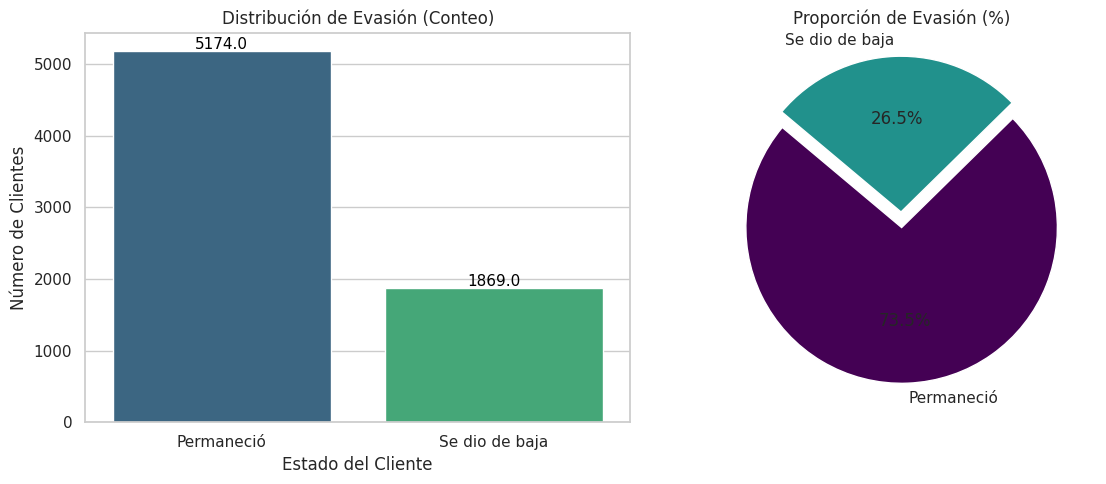

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ax = sns.countplot(x='Abandono', data=df_final, palette='viridis')
plt.title('Distribución de Evasión (Conteo)')
plt.xticks([0, 1], ['Permaneció', 'Se dio de baja'])
plt.xlabel('Estado del Cliente')
plt.ylabel('Número de Clientes')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.subplot(1, 2, 2)
counts = df_final['Abandono'].value_counts()
plt.pie(counts, labels=['Permaneció', 'Se dio de baja'], autopct='%1.1f%%',
        colors=['#440154', '#21918c'], startangle=140, explode=(0, 0.1))
plt.title('Proporción de Evasión (%)')

plt.tight_layout()
plt.show()

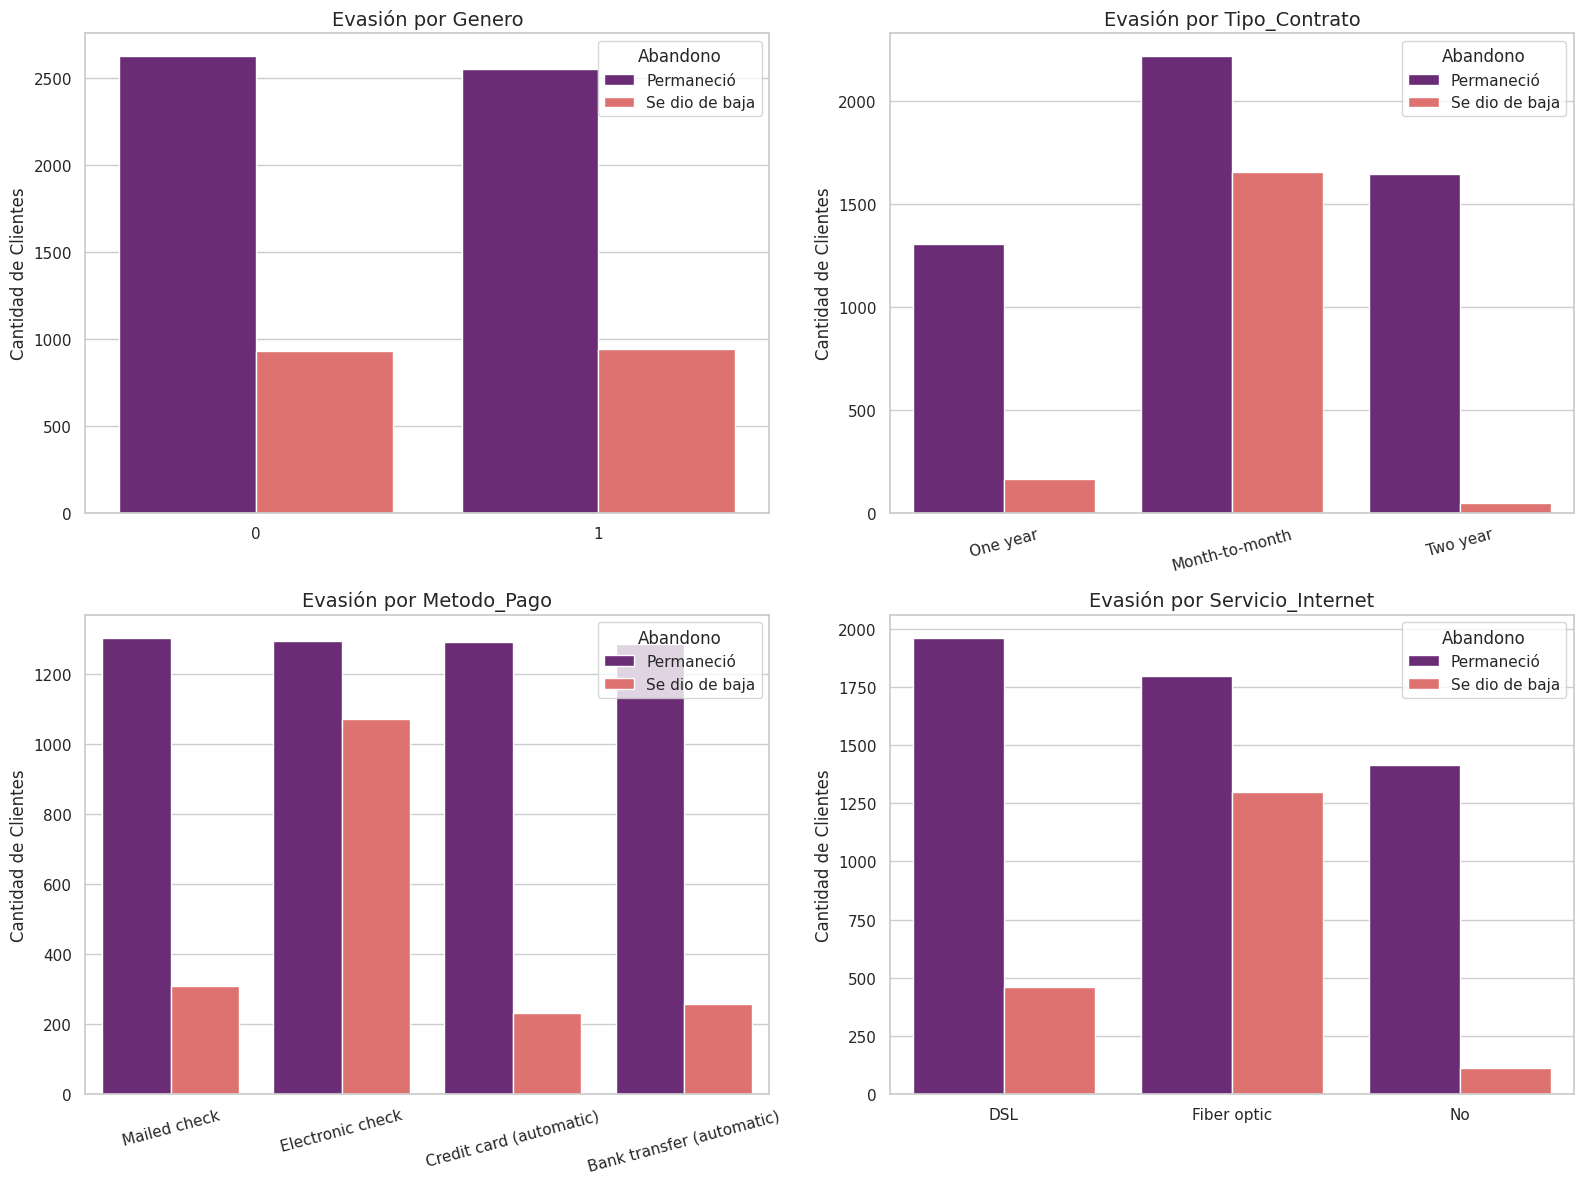

In [32]:
variables_analizar = ['Genero', 'Tipo_Contrato', 'Metodo_Pago', 'Servicio_Internet']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(variables_analizar):
    sns.countplot(x=col, hue='Abandono', data=df_final, ax=axes[i], palette='magma')

    axes[i].set_title(f'Evasión por {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad de Clientes')
    axes[i].legend(title='Abandono', labels=['Permaneció', 'Se dio de baja'])

    if col == 'Metodo_Pago' or col == 'Tipo_Contrato':
        axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

/tmp/ipykernel_538/283650061.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Abandono', y=col, data=df_final, ax=axes[i], palette='viridis')
/tmp/ipykernel_538/283650061.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Permaneció', 'Se dio de baja'])
/tmp/ipykernel_538/283650061.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Abandono', y=col, data=df_final, ax=axes[i], palette='viridis')
/tmp/ipykernel_538/283650061.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xt

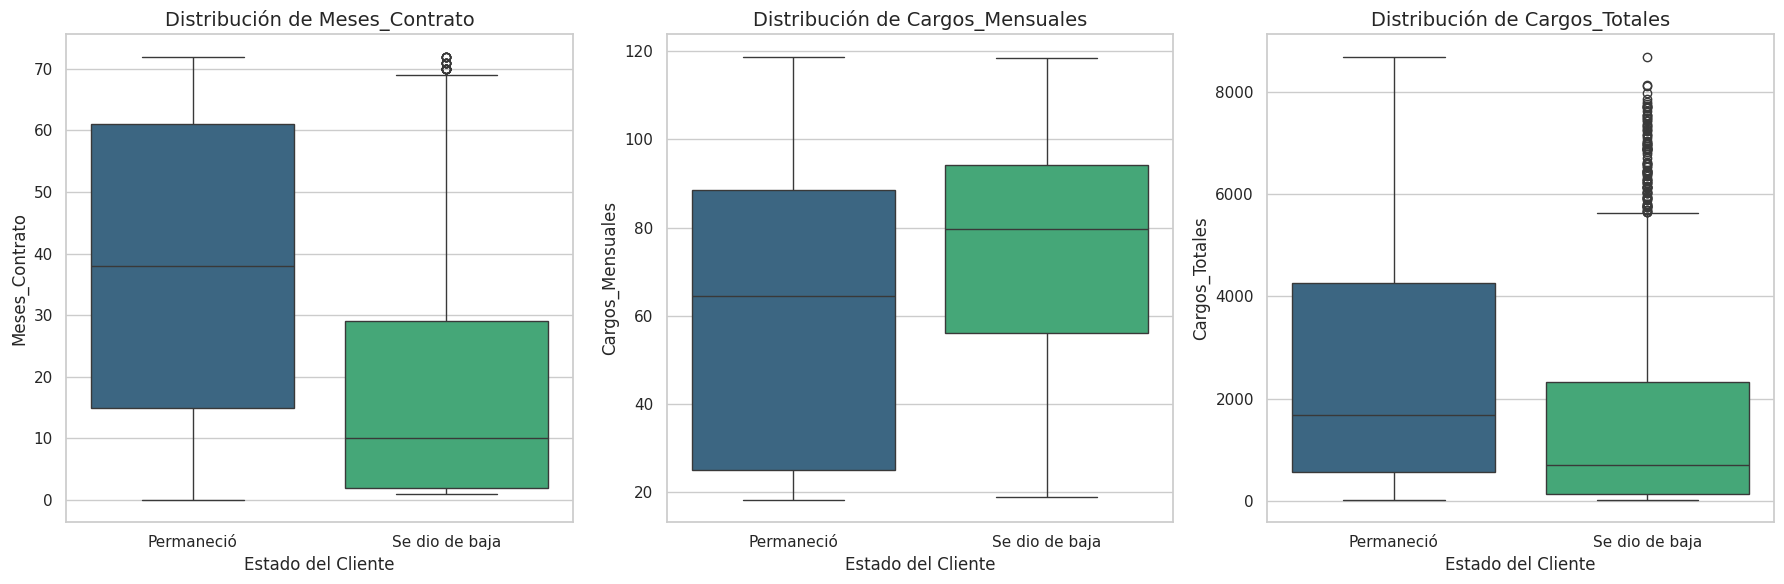

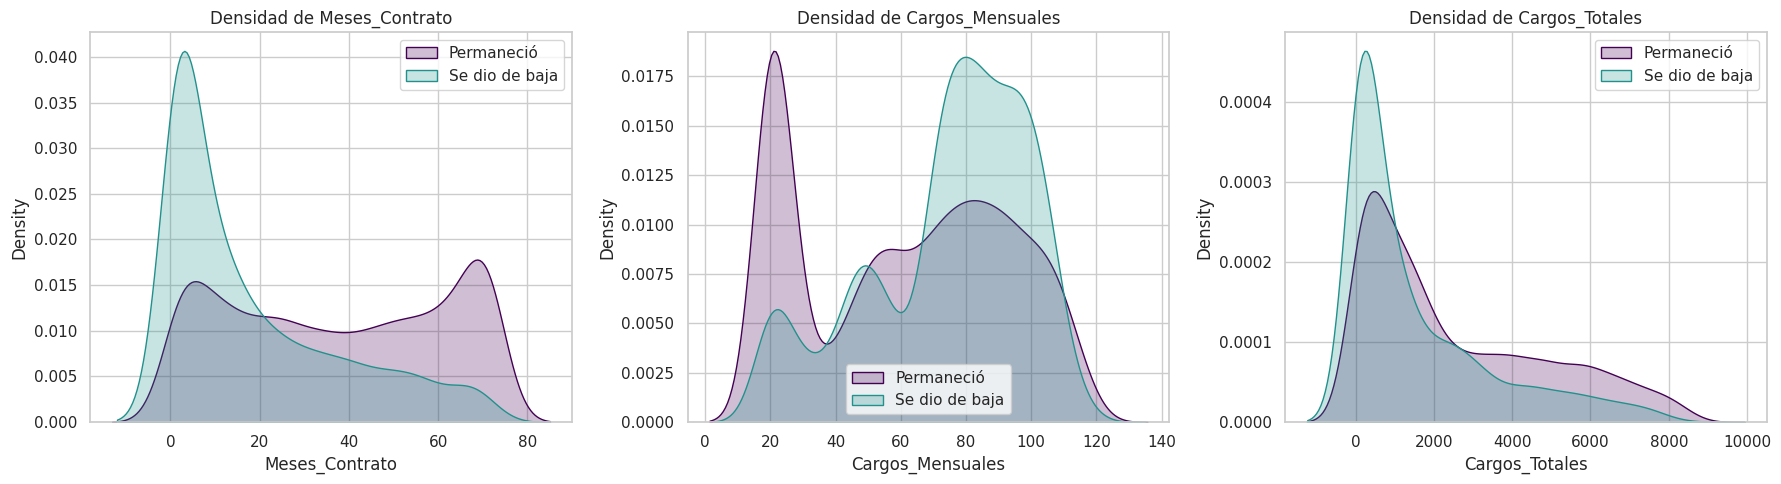

In [35]:
variables_num = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for i, col in enumerate(variables_num):
    sns.boxplot(x='Abandono', y=col, data=df_final, ax=axes[i], palette='viridis')

    axes[i].set_title(f'Distribución de {col}', fontsize=14)
    axes[i].set_xticklabels(['Permaneció', 'Se dio de baja'])
    axes[i].set_xlabel('Estado del Cliente')

plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 5))
for i, col in enumerate(variables_num):
    plt.subplot(1, 3, i+1)
    sns.kdeplot(df_final[df_final['Abandono'] == 0][col], label='Permaneció', fill=True, color='#440154')
    sns.kdeplot(df_final[df_final['Abandono'] == 1][col], label='Se dio de baja', fill=True, color='#21918c')
    plt.title(f'Densidad de {col}')
    plt.legend()

plt.tight_layout()
plt.show()

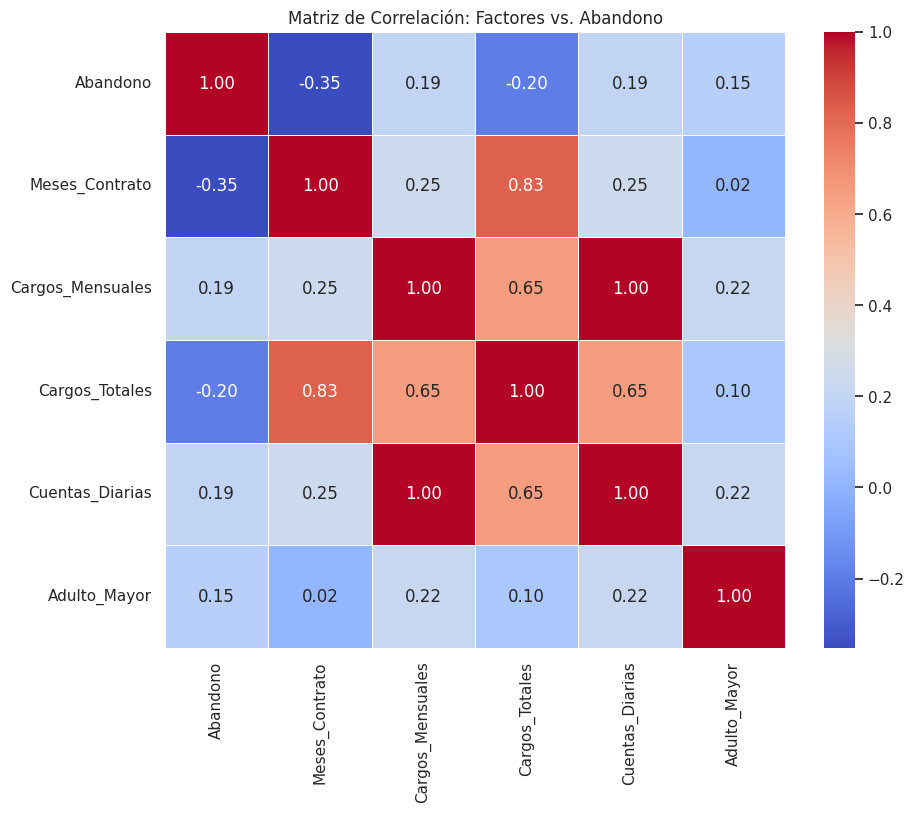

In [36]:
columnas_analisis = ['Abandono', 'Meses_Contrato', 'Cargos_Mensuales',
                     'Cargos_Totales', 'Cuentas_Diarias', 'Adulto_Mayor']

matriz_corr = df_final[columnas_analisis].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Factores vs. Abandono')
plt.show()

Correlación entre cantidad de servicios y abandono: -0.0877


/tmp/ipykernel_538/2060736210.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Servicios', y='Abandono', data=df_final, palette='Blues_d')


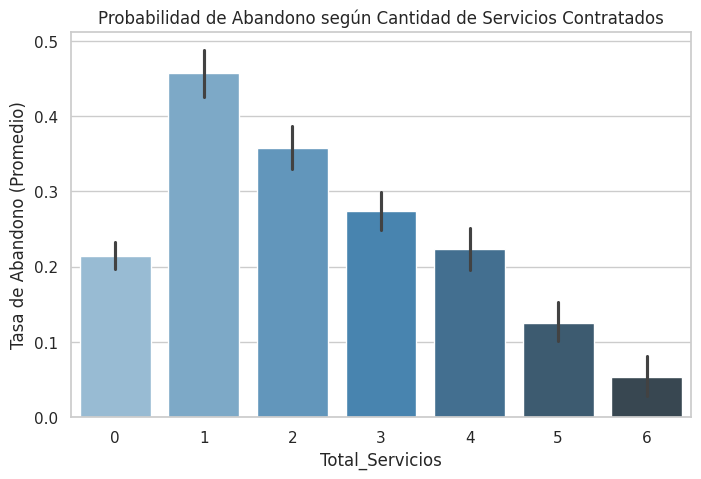

In [37]:
servicios = ['Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo',
             'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas']

df_temp = df_final.copy()
for col in servicios:
    df_temp[col] = df_temp[col].apply(lambda x: 1 if x == 'Yes' else 0)

df_final['Total_Servicios'] = df_temp[servicios].sum(axis=1)

corr_servicios = df_final[['Total_Servicios', 'Abandono']].corr().iloc[0,1]
print(f"Correlación entre cantidad de servicios y abandono: {corr_servicios:.4f}")

plt.figure(figsize=(8, 5))
sns.barplot(x='Total_Servicios', y='Abandono', data=df_final, palette='Blues_d')
plt.title('Probabilidad de Abandono según Cantidad de Servicios Contratados')
plt.ylabel('Tasa de Abandono (Promedio)')
plt.show()

#📄Informe final

# 📊 Informe Final: Análisis de Evasión de Clientes (Churn) - Telecom X

## 1. Introducción
El objetivo de este proyecto es analizar y comprender los factores que provocan la **evasión de clientes (Churn)** en la empresa Telecom X. La pérdida de clientes no solo afecta los ingresos directos, sino que incrementa los costos operativos debido a la necesidad de adquirir nuevos usuarios. Este informe sintetiza el proceso de ingeniería de datos y los hallazgos estratégicos obtenidos.



## 2. Limpieza y Tratamiento de Datos
Para transformar los datos crudos en información útil para el análisis, se realizaron los siguientes pasos:
* **Extracción y Normalización:** Se cargaron los datos desde una API JSON y se normalizaron las columnas anidadas (`customer`, `phone`, `internet`, `account`) para obtener una estructura tabular limpia.
* **Gestión de Inconsistencias:**
    * Se eliminaron los registros con valores vacíos en la columna **Abandono**.
    * Se convirtieron los *strings* vacíos en valores nulos (`NaN`) para su correcta identificación.
    * Se imputaron valores en la columna **Cargos_Totales** para clientes con antigüedad cero.
* **Estandarización:** * Se tradujeron todas las columnas al español para facilitar la comunicación con los interesados (*stakeholders*).
    * Se creó la columna **Cuentas_Diarias** para entender el impacto económico diario por cliente.
    * Se transformaron variables categóricas (Sí/No, Género) a valores numéricos binarios ($1$ y $0$).



## 3. Análisis Exploratorio de Datos (EDA)
El análisis reveló patrones críticos sobre quiénes son los clientes con mayor riesgo de fuga:
* **Tasa de Abandono:** Aproximadamente el **26.5%** de los clientes han cancelado el servicio.
* **Tipo de Contrato:** Los clientes con contratos **"Mes a Mes"** presentan una tasa de evasión drásticamente superior a los contratos de largo plazo.
* **Cargos Mensuales:** Se observó que los clientes que abandonan suelen tener cargos mensuales más elevados en comparación con los clientes leales.
* **Antigüedad (Tenure):** Existe una relación inversa; a menor tiempo en la empresa, mayor es la probabilidad de cancelar el servicio, especialmente en los primeros 6 meses.



## 4. Conclusiones e Insights
1. **El precio como detonante:** La correlación positiva entre los cargos mensuales y la evasión sugiere que el costo es una de las razones principales de salida.
2. **Barreras de Salida:** Los clientes que contratan más servicios adicionales (como seguridad online o soporte técnico) tienden a permanecer más tiempo, lo que indica que la diversificación de servicios aumenta la retención.
3. **Métodos de Pago:** El uso de **cheque electrónico** está altamente asociado con el abandono, mientras que los métodos automáticos fomentan la permanencia.

## 5. Recomendaciones Estratégicas
* **Fomentar la Lealtad:** Ofrecer incentivos o descuentos para migrar a los clientes de contratos mensuales a contratos de 1 o 2 años.
* **Atención Temprana:** Implementar programas de seguimiento y beneficios exclusivos para clientes nuevos durante su primer semestre de contrato.
* **Venta Cruzada (Cross-selling):** Promocionar paquetes de servicios adicionales para aumentar el valor percibido y dificultar la migración a la competencia.
* **Digitalización de Pagos:** Incentivar el uso de pagos automáticos para reducir la fricción en la facturación mensual.